In [1]:
%pip install ipykernel matplotlib numpy pandas scikit-learn seaborn requests

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pickle
from pathlib import Path
from zipfile import ZipFile

import pandas
import seaborn
import requests
from pandas import DataFrame
from matplotlib import pyplot
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

from helper import analyze_url

In [2]:
# Download dataset ZIP and extract dataset file.
if not Path("dataset.csv").exists():
    if not Path("dataset.zip").exists():
        response = requests.get("https://github.com/thiagola92/pucpos-qualidade/raw/refs/heads/main/backend/machine_learning/dataset.zip")
        assert response.status_code == 200, "Failed to get CSV from Github"
        Path("dataset.zip").write_bytes(response.content)
    
    ZipFile("dataset.zip").extract("dataset.csv")

# Load dataset.
dataset = pandas.read_csv("dataset.csv")

pandas.set_option("display.max_columns", None)
pandas.set_option('display.max_colwidth', None)
dataset.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µà¹‰ à¸‚à¹ˆà¸²à¸§à¸à¸µà¸¬à¸² à¸‚à¹ˆà¸²à¸§à¸šà¸±à¸™à¹€à¸—à¸´à¸‡ à¸­à¸±à¸žà¹€à¸”à¸—à¸ªà¸”à¹ƒà¸«à¸¡à¹ˆà¸—à¸¸à¸à¸§à¸±à¸™ &#8211; à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸à¸µà¸¬à¸² à¸‚à¹ˆà¸²à¸§à¸šà¸±à¸™à¹€à¸—à¸´à¸‡ à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µà¹‰ à¸­à¸±à¸›à¹€à¸”à¸•à¸‚à¹ˆà¸²à¸§à¸ªà¸²à¸£à¸£à¸§à¸”à¹€à¸£à¹‡à¸§à¸—à¸±à¸™à¹ƒà¸ˆ à¸žà¸£à¹‰à¸­à¸¡à¸£à¸±à¸šà¸Šà¸¡à¸ªà¸²à¸£à¸°à¸™à¹ˆà¸²à¸£à¸¹à¹‰à¸•à¹ˆà¸²à¸‡à¹† à¹„à¸”à¹‰à¸Ÿà¸£à¸µà¸•à¸¥à¸­à¸” 24à¸Šà¸±à¹ˆà¸§à¹‚à¸¡à¸‡,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medicine,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


In [3]:
# Storing original dataset for comparing data with the new dataset.
dataset_original = dataset.drop(columns=[
    # Strings
    "FILENAME",
    "URL",
    "Domain",
    "TLD",
    "Title",
    
    # I don't know the logic behind it.
    "URLSimilarityIndex",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
    
    # Needs robots.txt file
    "Robots",
    
    # Needs HAR file
    "NoOfURLRedirect",
    "NoOfSelfRedirect", 
    
    # Needs page content
    "LineOfCode",
    "LargestLineLength",
    "HasTitle",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "HasFavicon",
    "IsResponsive",
    "HasDescription",
    "NoOfPopup",
    "NoOfiFrame",
    "HasExternalFormSubmit",
    "HasSocialNet",
    "HasSubmitButton",
    "HasHiddenFields",
    "HasPasswordField",
    "Bank",
    "Pay",
    "Crypto",
    "HasCopyrightInfo",
    "NoOfImage",
    "NoOfCSS",
    "NoOfJS",
    "NoOfSelfRef",
    "NoOfEmptyRef",
    "NoOfExternalRef",
])

dataset_original.head()

,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,label
0,31,24,0,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,1
1,23,16,0,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,1
2,29,22,0,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,1
3,26,19,0,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,1
4,33,26,0,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,1


In [4]:
# Create a new dataset, using logic that we can reproduce.
data_remake = {
    "URLLength": [],
    "DomainLength": [],
    "IsDomainIP": [],
    "TLDLength": [],
    "NoOfSubDomain": [],
    "HasObfuscation": [],
    "NoOfObfuscatedChar": [],
    "ObfuscationRatio": [],
    "NoOfLettersInURL": [],
    "LetterRatioInURL": [],
    "NoOfDegitsInURL": [],
    "DegitRatioInURL": [],
    "NoOfEqualsInURL": [],
    "NoOfQMarkInURL": [],
    "NoOfAmpersandInURL": [],
    "NoOfOtherSpecialCharsInURL": [],
    "SpacialCharRatioInURL": [],
    "IsHTTPS": [],
    "label": [],
}

for value in dataset[["URL", "label"]].values:
    url = value[0]
    result = analyze_url(url)

    for k, v in result.items():
        data_remake[k].extend(v)
    
    data_remake["label"].append(value[1])

dataset_new = DataFrame(data=data_remake, columns=list(data_remake.keys()))

dataset_new.head()

,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,label
0,32,24,0,3,1,0,0,0.0,27,0.843750,0,0.0,0,0,0,1,0.031250,1,1
1,24,16,0,2,1,0,0,0.0,18,0.750000,0,0.0,0,0,0,2,0.083333,1,1
2,30,22,0,2,2,0,0,0.0,24,0.800000,0,0.0,0,0,0,2,0.066667,1,1
3,27,19,0,3,1,0,0,0.0,22,0.814815,0,0.0,0,0,0,1,0.037037,1,1
4,34,26,0,3,1,0,0,0.0,29,0.852941,0,0.0,0,0,0,1,0.029412,1,1


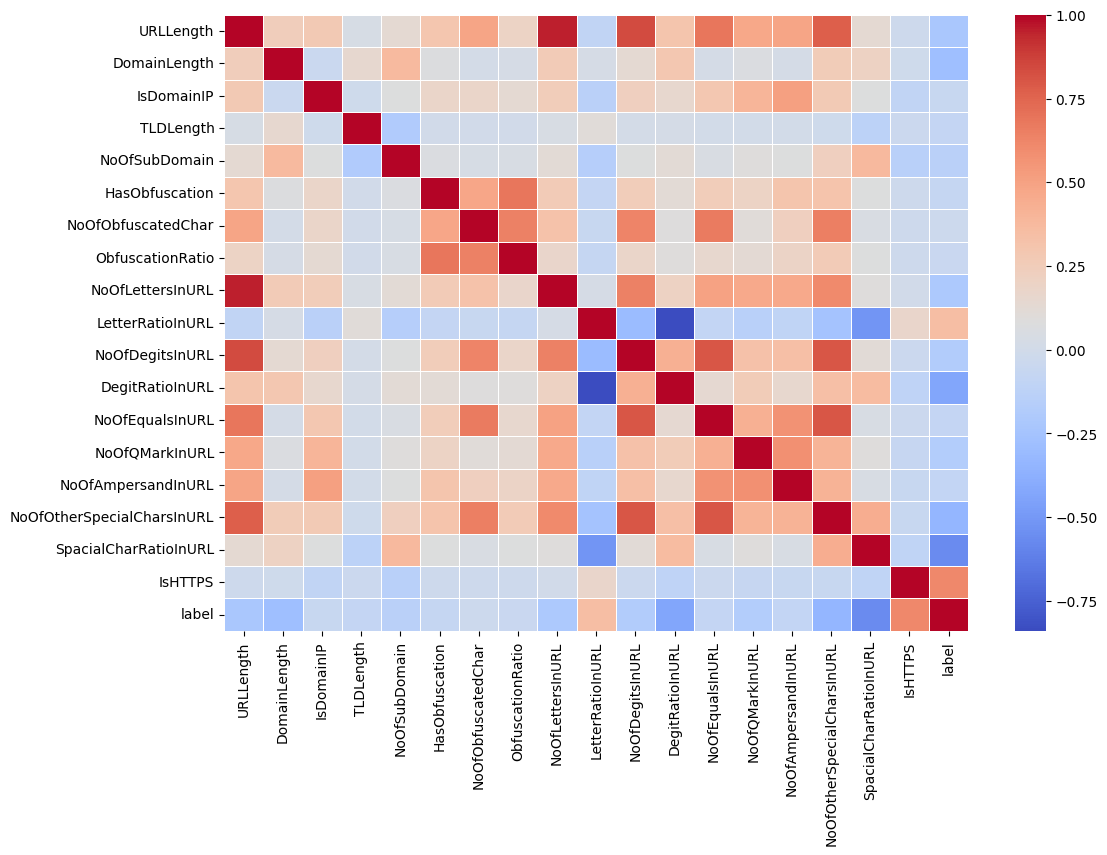

In [5]:
# Plot heatmap.
pyplot.figure(figsize=(12,8))
seaborn.heatmap(dataset_new.corr('pearson'), annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
pyplot.show()

In [38]:
# Split between features and classification.
X = dataset_new.drop(columns=["label"])
y = dataset_new["label"]

# Path to save model.
output_path = Path("./model.pkl")

seed = 7
kfold = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=seed
)

# Split dataset between training and tests.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    shuffle=True,
    random_state=seed,
    stratify=y
)

# Classifiers.
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
random_forest = ('RF', RandomForestClassifier())
svm = ('SVM', SVC())

# Transformers.
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Pipelines.
pipelines = [
    # Dataset original.
    ('orig-KNN', Pipeline([knn])),
    ('orig-CART', Pipeline([cart])),
    ('orig-NB', Pipeline([naive_bayes])),
    ('orig-RF', Pipeline([random_forest])),
    # ('SVM-orig', Pipeline([svm])),
    
    # Dataset standarized.
    ('stand-KNN', Pipeline([standard_scaler, knn])),
    ('stand-CART', Pipeline([standard_scaler, cart])),
    ('stand-NB', Pipeline([standard_scaler, naive_bayes])),
    ('stand-RF', Pipeline([standard_scaler, random_forest])),
    # ('SVM-padr', Pipeline([standard_scaler, svm])),

    # Dataset normalized.
    ('norm-KNN', Pipeline([min_max_scaler, knn])),
    ('norm-CART', Pipeline([min_max_scaler, cart])),
    ('norm-NB', Pipeline([min_max_scaler, naive_bayes])),
    ('norm-RF', Pipeline([min_max_scaler, random_forest])),
    # ('SVM-norm', Pipeline([min_max_scaler, svm])),
]

In [39]:
results = []

# Check the result when training with X_train and y_train.
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    
    results.append((name, model, cv_results))
    
    print("%s: %.5f (%.5f)" % (name, cv_results.mean(), cv_results.std()))

orig-KNN: 0.99447 (0.00041)
orig-CART: 0.99647 (0.00035)
orig-NB: 0.91961 (0.00219)
orig-RF: 0.99677 (0.00053)
stand-KNN: 0.99594 (0.00031)
stand-CART: 0.99647 (0.00042)
stand-NB: 0.89800 (0.00278)
stand-RF: 0.99673 (0.00045)
norm-KNN: 0.99596 (0.00021)
norm-CART: 0.99647 (0.00042)
norm-NB: 0.90494 (0.00252)
norm-RF: 0.99678 (0.00045)


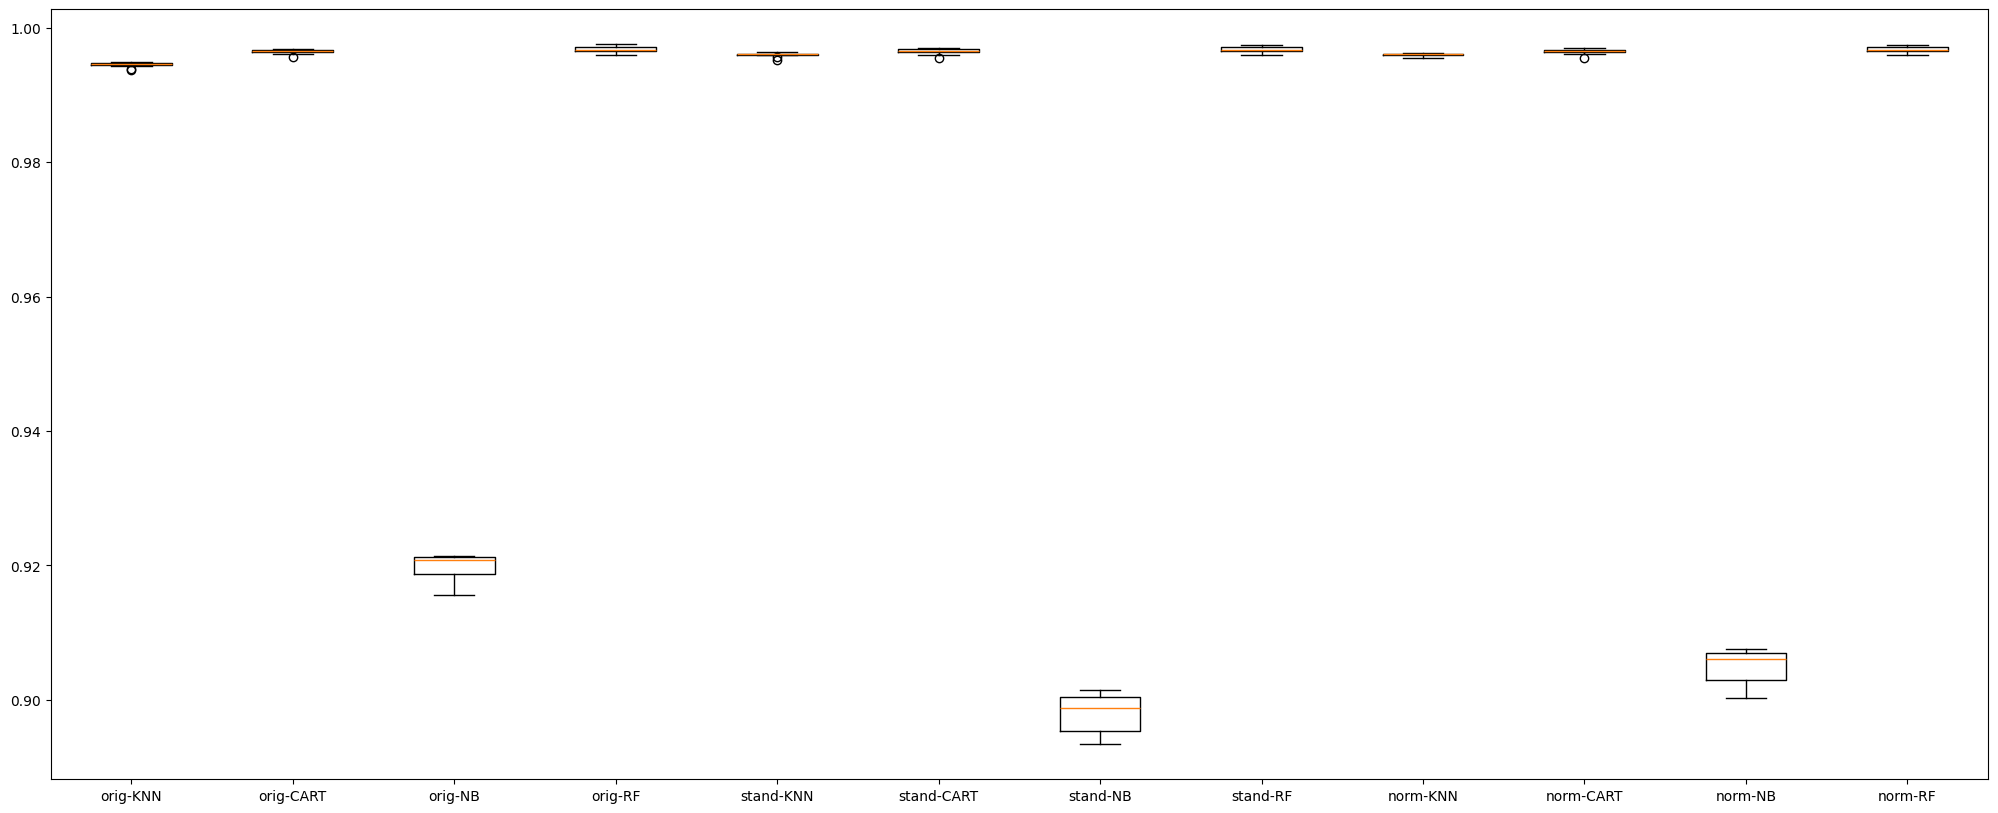

In [40]:
# Plot results boxplots.
figure = pyplot.figure(figsize=(25,10))
axes = figure.add_subplot(111)

pyplot.boxplot([r[2] for r in results])
axes.set_xticklabels([r[0] for r in results])
pyplot.show()

In [41]:
# Get the best score.
best_name = None
best_model = None
best_scoring = 0

for name, model, cv_results in results:
    if cv_results.mean() > best_scoring:
        best_scoring = cv_results.mean()
        best_name = name
        best_model = model

print(f"Best model: {best_name}")

Best model: norm-RF


In [42]:
# Test predictions.
best_model.fit(X_train, y_train)
predictions = best_model.predict(X_test)

accuracy_score(y_test, predictions)

0.9969889098581395

In [43]:
# Train using full dataset and save model.
best_model.fit(X, y)

with open(output_path, "wb") as f:
    pickle.dump(best_model, f)

In [44]:
# Load model from file.
model = pickle.loads(output_path.read_bytes())

# Create a simple testing function.
def test_url(url, expected):
    data = analyze_url("https://www.google.com")
    dataframe = DataFrame(data=data, columns=list(data.keys()))
    result = model.predict(dataframe)[0]

    print(expected == result, url)

# Expected not to be phishing.
test_url("https://www.google.com", 1)
test_url("https://www.facebook.com", 1)
test_url("https://www.southbankmosaics.com", 1)
test_url("https://www.voicefmradio.co.uk", 1)
test_url("http://www.voicefm324234radsio.com.uk/%20%20%20?path=test%23", 1)

# Expected to be phishing.
test_url("http://www.kuradox92.lima-city.de", 0)
test_url("http://www.f0519141.xsph.ru", 0)
test_url("https://bancolombia.com1home0892.repl.co/?2", 0)
test_url("http://bancolombia.com1home0892.repl.co/?2%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32", 0)

True https://www.google.com
True https://www.facebook.com
True https://www.southbankmosaics.com
True https://www.voicefmradio.co.uk
True http://www.voicefm324234radsio.com.uk/%20%20%20?path=test%23
False http://www.kuradox92.lima-city.de
False http://www.f0519141.xsph.ru
False https://bancolombia.com1home0892.repl.co/?2
False http://bancolombia.com1home0892.repl.co/?2%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32
